# 02 — Lung Cancer Risk: Deep Learning (MLP)

**Component 2 of 4 — RespiraAI Deployment Capstone**

Solves the *identical* task as `01_lung_cancer_ml.ipynb` — same features, same target, same `random_state=42` train/test split — but with a small PyTorch feedforward network instead of classical ML. Keeping everything else fixed isolates the one variable that actually changed: the model itself, which is what makes the comparison at the end fair.


In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)


In [3]:
def find_data_file(filename):
    candidates = [filename, os.path.join("data", filename), os.path.join("day1_data", "data", filename), os.path.join("..", "data", filename), os.path.join(".", filename)]
    for c in candidates:
        if os.path.exists(c):
            return c
    raise FileNotFoundError(f"Could not find {filename!r} in any of: {candidates}")

df = pd.read_csv(find_data_file("lung_cancer.csv"))
df.columns = [c.strip().upper().replace(" ", "_") for c in df.columns]
df["GENDER"] = df["GENDER"].map({"M": 1, "F": 0})
df["LUNG_CANCER"] = df["LUNG_CANCER"].map({"YES": 1, "NO": 0})
symptom_cols = [c for c in df.columns if c not in ("GENDER", "AGE", "LUNG_CANCER")]
for c in symptom_cols:
    df[c] = df[c] - 1

FEATURE_COLUMNS = [c for c in df.columns if c != "LUNG_CANCER"]
X = df[FEATURE_COLUMNS].values.astype(np.float32)
y = df["LUNG_CANCER"].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("train:", X_train.shape, " test:", X_test.shape)


train: (247, 15)  test: (62, 15)


## Scale features

Tree-based models (Random Forest) don't care about feature scale — a split on `AGE` at 60 works the same whether age ranges 0-100 or 0-1. Gradient-based models (this MLP) very much do care: unscaled `AGE` (range ~20-90) would dominate gradient updates over the 0/1 symptom columns purely because of its larger numeric range, not because it's actually more predictive. `StandardScaler` (zero mean, unit variance per column) neutralizes that. Fit on train only, same discipline as always.

In [4]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test_s, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print(X_train_t.shape, y_train_t.shape)


torch.Size([247, 15]) torch.Size([247, 1])


## Model

A small 2-hidden-layer MLP — 15 input features doesn't need or benefit from a deep or wide network. `Dropout(0.2)` after the first hidden layer is a cheap regularizer against overfitting on a training set this small (247 rows).

In [5]:
class LungCancerMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),  # raw logit -- BCEWithLogitsLoss applies sigmoid internally
        )

    def forward(self, x):
        return self.net(x)

model = LungCancerMLP(in_dim=X_train_t.shape[1])
print(model)
print("trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))


LungCancerMLP(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=1, bias=True)
  )
)
trainable params: 1057


## Handle class imbalance in the loss

Classical ML got `class_weight='balanced'` for free from scikit-learn. PyTorch's equivalent is `pos_weight` on `BCEWithLogitsLoss`: since YES (label=1) is the *majority* class here (~87%), `pos_weight = n_negative / n_positive` works out **less than 1**, which *down*-weights how much the loss cares about getting the majority class right — correctly rebalancing attention toward the minority NO class, the same intent as `class_weight='balanced'`.

In [6]:
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32)
print(f"n_pos={int(n_pos)}  n_neg={int(n_neg)}  pos_weight={pos_weight.item():.3f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)


n_pos=216  n_neg=31  pos_weight=0.144


## Train

Full-batch gradient descent (all 247 training rows per step) — the dataset is small enough that mini-batching would add complexity for no benefit here.

epoch  20  loss 0.0478
epoch  40  loss 0.0334
epoch  60  loss 0.0234
epoch  80  loss 0.0160
epoch 100  loss 0.0126


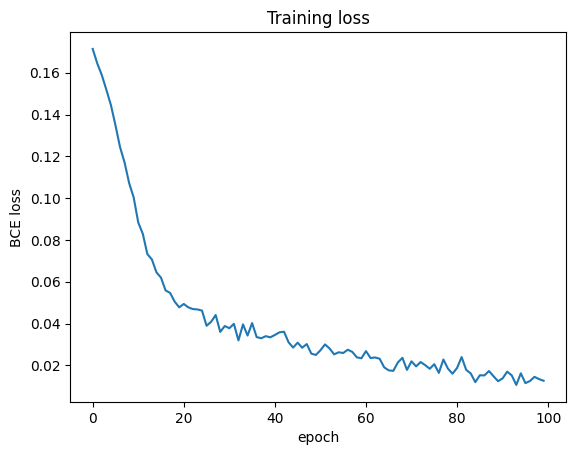

In [7]:
EPOCHS = 100
history = []

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_t)
    loss = criterion(logits, y_train_t)
    loss.backward()
    optimizer.step()
    history.append(loss.item())
    if (epoch + 1) % 20 == 0:
        print(f"epoch {epoch+1:>3}  loss {loss.item():.4f}")

import matplotlib.pyplot as plt
plt.plot(history)
plt.title("Training loss")
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.show()


## Evaluate

Same metrics as Notebook 1, same test set, so these numbers are directly comparable.

In [8]:
model.eval()
with torch.no_grad():
    test_logits = model(X_test_t)
    test_probs = torch.sigmoid(test_logits)
    test_preds = (test_probs > 0.5).float()

acc = accuracy_score(y_test_t.numpy(), test_preds.numpy())
f1 = f1_score(y_test_t.numpy(), test_preds.numpy())
print(f"MLP test accuracy={acc:.3f}  f1={f1:.3f}")
print(classification_report(y_test_t.numpy(), test_preds.numpy(), target_names=["NO", "YES"]))


MLP test accuracy=0.903  f1=0.942
              precision    recall  f1-score   support

          NO       0.58      0.88      0.70         8
         YES       0.98      0.91      0.94        54

    accuracy                           0.90        62
   macro avg       0.78      0.89      0.82        62
weighted avg       0.93      0.90      0.91        62



## ML vs DL, side by side

Fill in your own Notebook-1 numbers here to compare directly (they'll be close to: Random Forest ~0.90 accuracy / 0.94 F1, with NO-class recall around 0.6; Logistic Regression similar accuracy but near-perfect NO-class recall at the cost of more false positives).

In [9]:
print("MLP        :", f"accuracy={acc:.3f}  f1={f1:.3f}")
print("(compare against the Random Forest / Logistic Regression numbers printed in notebook 01)")

# On a dataset this small (309 rows, 15 simple binary/numeric features), don't expect the MLP
# to blow classical ML out of the water -- and if it doesn't, that IS the finding, not a bug.
# Deep learning's advantage shows up when there's enough data and enough feature complexity
# (raw pixels, raw audio, raw text) that hand-engineered features and shallow models genuinely
# fall behind. For 15 clean tabular yes/no features and 309 rows, a well-tuned Random Forest is
# a completely reasonable production choice -- this comparison is the evidence for that claim,
# not just an assertion of it.


MLP        : accuracy=0.903  f1=0.942
(compare against the Random Forest / Logistic Regression numbers printed in notebook 01)


## Save the model


In [10]:
MODELS_DIR = "../models" if os.path.isdir("..") else "models"
os.makedirs(MODELS_DIR, exist_ok=True)

torch.save(model.state_dict(), os.path.join(MODELS_DIR, "lung_cancer_mlp.pt"))
import joblib
joblib.dump(scaler, os.path.join(MODELS_DIR, "lung_cancer_scaler.pkl"))
print(f"Saved MLP weights + scaler to {MODELS_DIR}/")

# NOTE: the scaler is saved alongside the model deliberately -- unlike the Random Forest,
# this model needs its inputs scaled identically at inference time (in the FastAPI app) or
# predictions will be wrong. This is exactly the kind of preprocessing-inference mismatch
# that's easy to introduce by accident during deployment; saving the fitted scaler avoids it.


Saved MLP weights + scaler to ../models/


## Notes

- Same `RANDOM_STATE=42` split as Notebook 1 makes this a genuine apples-to-apples comparison, not two different problems dressed up as one.
- The MLP needed an explicit scaling step that Random Forest didn't — a good concrete example of why "just swap in a neural net" isn't a drop-in replacement; the whole preprocessing pipeline around it changes too, and that pipeline (the `scaler.pkl`) has to travel with the model into deployment.
- `pos_weight` in `BCEWithLogitsLoss` is PyTorch's version of `class_weight='balanced'` — same idea, different API, and easy to forget since it's not the default.
- Next: `03_xray_cv.ipynb` moves to the computer vision component — a genuinely different data modality (images) where deep learning's advantage over classical ML is much more clear-cut than it was here.